# CPE 342 - Assignment 1: OLS Regression

| Name | Student ID |
|---|---|
| Kiatisak Markmeeshap | 67070501005 |

X = advertising budget (thousand \$) &nbsp;|&nbsp; Y = sales (thousand units)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.precision", 4)

df = pd.DataFrame({
    "month":        [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "budget_kusd":  [3.0, 5.0, 2.0, 7.0, 8.0, 1.0, 4.0, 6.0, 9.0, 10.0],
    "sales_kunits": [6.0, 9.0, 4.0, 10.0, 12.0, 3.0, 7.0, 8.0, 13.0, 15.0],
}).set_index("month")

x = df["budget_kusd"].to_numpy(dtype=float)
y = df["sales_kunits"].to_numpy(dtype=float)
n = len(x)
df.T

month,1,2,3,4,5,6,7,8,9,10
budget_kusd,3.0,5.0,2.0,7.0,8.0,1.0,4.0,6.0,9.0,10.0
sales_kunits,6.0,9.0,4.0,10.0,12.0,3.0,7.0,8.0,13.0,15.0


---
## 1a. OLS fit

Model:

$$y_i = \beta_0 + \beta_1 x_i + \varepsilon_i$$

OLS chooses $\beta_0, \beta_1$ that minimise:

$$\mathrm{SSE} = \sum_{i=1}^{n} \left(y_i - \beta_0 - \beta_1 x_i\right)^2$$

Setting both partial derivatives to zero gives the **normal equations**:

$$\left\{
\begin{aligned}
n\,\beta_0 \;+\; \left(\textstyle\sum x_i\right)\beta_1 &= \textstyle\sum y_i \\[6pt]
\left(\textstyle\sum x_i\right)\beta_0 \;+\; \left(\textstyle\sum x_i^2\right)\beta_1 &= \textstyle\sum x_i y_i
\end{aligned}
\right.$$

Five sums are needed: $n$, $\sum x_i$, $\sum y_i$, $\sum x_i y_i$, $\sum x_i^2$.

In [2]:
sum_x, sum_y = x.sum(), y.sum()
sum_xy, sum_xx = (x * y).sum(), (x ** 2).sum()
x_bar, y_bar = x.mean(), y.mean()

print(f"n = {n}, sum x = {sum_x:g}, sum y = {sum_y:g}, "
      f"sum xy = {sum_xy:g}, sum x^2 = {sum_xx:g}")
print(f"x_bar = {x_bar:g}, y_bar = {y_bar:g}")

pd.DataFrame({"x": x, "y": y, "x*y": x * y, "x^2": x ** 2}, index=df.index).T

n = 10, sum x = 55, sum y = 87, sum xy = 583, sum x^2 = 385
x_bar = 5.5, y_bar = 8.7


month,1,2,3,4,5,6,7,8,9,10
x,3.0,5.0,2.0,7.0,8.0,1.0,4.0,6.0,9.0,10.0
y,6.0,9.0,4.0,10.0,12.0,3.0,7.0,8.0,13.0,15.0
x*y,18.0,45.0,8.0,70.0,96.0,3.0,28.0,48.0,117.0,150.0
x^2,9.0,25.0,4.0,49.0,64.0,1.0,16.0,36.0,81.0,100.0


---
## 1b. Coefficients - three methods

### Method 1: closed form

Solve the two normal equations by hand:

$$\beta_1 = \frac{n\sum x_i y_i - \sum x_i \sum y_i}{n\sum x_i^2 - \left(\sum x_i\right)^2},
\qquad \beta_0 = \bar{y} - \beta_1 \bar{x}$$

In [3]:
beta1_scalar = (n * sum_xy - sum_x * sum_y) / (n * sum_xx - sum_x ** 2)
beta0_scalar = y_bar - beta1_scalar * x_bar

print(f"beta_1 = ({n}*{sum_xy:g} - {sum_x:g}*{sum_y:g}) / "
      f"({n}*{sum_xx:g} - {sum_x:g}^2) = {beta1_scalar:.6f}")
print(f"beta_0 = {y_bar:g} - {beta1_scalar:.6f}*{x_bar:g} = {beta0_scalar:.6f}")

beta_1 = (10*583 - 55*87) / (10*385 - 55^2) = 1.266667
beta_0 = 8.7 - 1.266667*5.5 = 1.733333


### Method 2: matrix normal equations

Put the data in the design matrix $\mathbf{X} = [\,\mathbf{1}\;\;\mathbf{x}\,]$:

$$\mathbf{X}^\top\mathbf{X}\,\boldsymbol{\beta} = \mathbf{X}^\top\mathbf{y}
\quad\Longrightarrow\quad
\boldsymbol{\beta} = \left(\mathbf{X}^\top\mathbf{X}\right)^{-1}\mathbf{X}^\top\mathbf{y}$$

$$\mathbf{X}^\top\mathbf{X} = \begin{bmatrix} n & \sum x_i \\ \sum x_i & \sum x_i^2\end{bmatrix},
\qquad \mathbf{X}^\top\mathbf{y} = \begin{bmatrix} \sum y_i \\ \sum x_i y_i\end{bmatrix}$$

Row by row this is the same pair of normal equations - but it still works with any
number of predictors, which method 1 does not.

In [4]:
X = np.column_stack([np.ones(n), x])
beta0, beta1 = np.linalg.solve(X.T @ X, X.T @ y)   # solve is preferred over inv()

print("X'X =\n", X.T @ X)
print("X'y =", X.T @ y)
print(f"\nbeta_0 = {beta0:.6f}, beta_1 = {beta1:.6f}")

X'X =
 [[ 10.  55.]
 [ 55. 385.]]
X'y = [ 87. 583.]

beta_0 = 1.733333, beta_1 = 1.266667


### Method 3: statsmodels (verification)

An independent implementation, used only to confirm methods 1 and 2.

In [5]:
import statsmodels.api as sm

model = sm.OLS(endog=y, exog=X).fit()   # X already has the constant column

pd.DataFrame({
    "beta_0 (intercept)": [beta0_scalar, beta0, model.params[0]],
    "beta_1 (slope)":     [beta1_scalar, beta1, model.params[1]],
}, index=["1. closed form", "2. matrix", "3. statsmodels"])

,beta_0 (intercept),beta_1 (slope)
1. closed form,1.7333,1.2667
2. matrix,1.7333,1.2667
3. statsmodels,1.7333,1.2667


---
## 1c. Fitted line

$$\boxed{\;\hat{y} = 1.7333 + 1.2667\,x\;}$$

$x$ in thousand dollars, $\hat{y}$ in thousand units.

---
## 2a. Meaning of the slope and intercept

$$\beta_1 = 1.2667 \;\frac{\text{k units}}{\text{k\$}}, \qquad \beta_0 = 1.7333 \text{ k units at } x = 0$$

In [6]:
print(f"beta_1 = {beta1:.4f} k units per k$  = {beta1 * 1000:,.0f} units per extra $1,000")
print(f"beta_0 = {beta0:.4f} k units         = {beta0 * 1000:,.0f} units at zero advertising")
print(f"observed x range: {x.min():g} to {x.max():g} k$   (x = 0 is outside it)")

beta_1 = 1.2667 k units per k$  = 1,267 units per extra $1,000
beta_0 = 1.7333 k units         = 1,733 units at zero advertising
observed x range: 1 to 10 k$   (x = 0 is outside it)


**Explanation**

**Slope** บอกว่าถ้าหากเราเพิ่มค่า $x$ ซึ่งก็คือ Advertising Budget ขึ้น 1k Dollar
ยอดขายจะเพิ่มขึ้นประมาณ 1.2667k Unit

ตัวอย่างเช่น ถ้าเราลงงบอยู่ที่ 5k Dollar โมเดลจะทำนายยอดขายได้ 8.07k Unit
พอเพิ่มงบเป็น 6k Dollar ยอดขายก็จะขึ้นเป็น 9.33k Unit

**Intercept** เปรียบได้เหมือนค่าตั้งต้นของโมเดล โดยที่หากเราไม่ลงทุนอะไรเลย
ก็คือ 0k Dollar โมเดลจะทำนายว่ายังขายได้อยู่ประมาณ 1.7333k Unit

แต่ต้องระวังไว้ว่างบต่ำสุดที่มีในข้อมูลจริงคือ 1k Dollar ไม่เคยมีเดือนไหนที่ไม่ลงโฆษณาเลยสักครั้ง
ค่า Intercept นี้จึงเป็นแค่ค่าที่ได้จากการลากเส้นออกไปนอกช่วงข้อมูล ไม่ใช่ข้อเท็จจริงที่ยืนยันได้
จากข้อมูลชุดนี้

---
## 2b. Prediction at a budget of \$12,000

\$12,000 $\Rightarrow x = 12$ (X is in thousand dollars):

$$\hat{y}(12) = 1.7333 + 1.2667 \times 12 = 16.9333 \text{ k units}$$

Observed range is $x \in [1, 10]$, so this is an **extrapolation**.

In [7]:
x_new = 12_000 / 1_000
y_pred = beta0 + beta1 * x_new

print(f"y_hat({x_new:g}) = {y_pred:.4f} k units = about {y_pred * 1000:,.0f} units")
print(f"inside observed range 1-10? {bool(x.min() <= x_new <= x.max())}  -> extrapolation")

y_hat(12) = 16.9333 k units = about 16,933 units
inside observed range 1-10? False  -> extrapolation


**Explanation**

**Prediction** ถ้างบโฆษณาอยู่ที่ 12,000 Dollar เราต้องแทนค่าเป็น $x = 12$ ไม่ใช่ 12000
เพราะ X มีหน่วยเป็น k Dollar อยู่แล้ว

แทนลงในสมการจะได้ $\hat{y} = 1.7333 + 1.2667 \times 12 = 16.9333$ ก็คือโมเดลทำนายว่า
จะขายได้ประมาณ 16.9333k Unit หรือราว ๆ 16,933 Unit

**ข้อควรระวัง** งบที่มีในข้อมูลจริงอยู่แค่ช่วง 1k ถึง 10k Dollar การทำนายที่ 12k Dollar
จึงเป็นการ extrapolate ออกไปนอกช่วงข้อมูล ตัวเลขที่ได้ถูกต้องตามสมการ
แต่ไม่มีอะไรรับประกันว่ายอดขายจริงจะยังเพิ่มขึ้นเป็นเส้นตรงแบบนี้

---
## 3a. R-squared

$$\mathrm{SSE} = \sum \left(y_i - \hat{y}_i\right)^2, \qquad
\mathrm{SST} = \sum \left(y_i - \bar{y}\right)^2, \qquad
R^2 = 1 - \frac{\mathrm{SSE}}{\mathrm{SST}}$$

In [8]:
y_hat = beta0 + beta1 * x
residuals = y - y_hat

sse = (residuals ** 2).sum()
sst = ((y - y_bar) ** 2).sum()
r_squared = 1 - sse / sst

print(f"SSE = {sse:.4f},  SST = {sst:.4f}")
print(f"R^2 = 1 - {sse:.4f}/{sst:.4f} = {r_squared:.4f}   ({r_squared * 100:.2f}%)")
print(f"check: statsmodels R^2 = {model.rsquared:.4f},  sum of residuals = {residuals.sum():.2e}")

pd.DataFrame({
    "x": x, "y": y, "y_hat": y_hat,
    "residual": residuals, "residual^2": residuals ** 2,
}, index=df.index).T

SSE = 3.7333,  SST = 136.1000
R^2 = 1 - 3.7333/136.1000 = 0.9726   (97.26%)
check: statsmodels R^2 = 0.9726,  sum of residuals = -5.33e-15


month,1,2,3,4,5,6,7,8,9,10
x,3.0000,5.0000,2.0000,7.00,8.0000,1.0000e+00,4.00,6.0000,9.0000,10.00
y,6.0000,9.0000,4.0000,10.00,12.0000,3.0000e+00,7.00,8.0000,13.0000,15.00
y_hat,5.5333,8.0667,4.2667,10.60,11.8667,3.0000e+00,6.80,9.3333,13.1333,14.40
residual,0.4667,0.9333,-0.2667,-0.60,0.1333,-8.8818e-16,0.20,-1.3333,-0.1333,0.60
residual^2,0.2178,0.8711,0.0711,0.36,0.0178,7.8886e-31,0.04,1.7778,0.0178,0.36


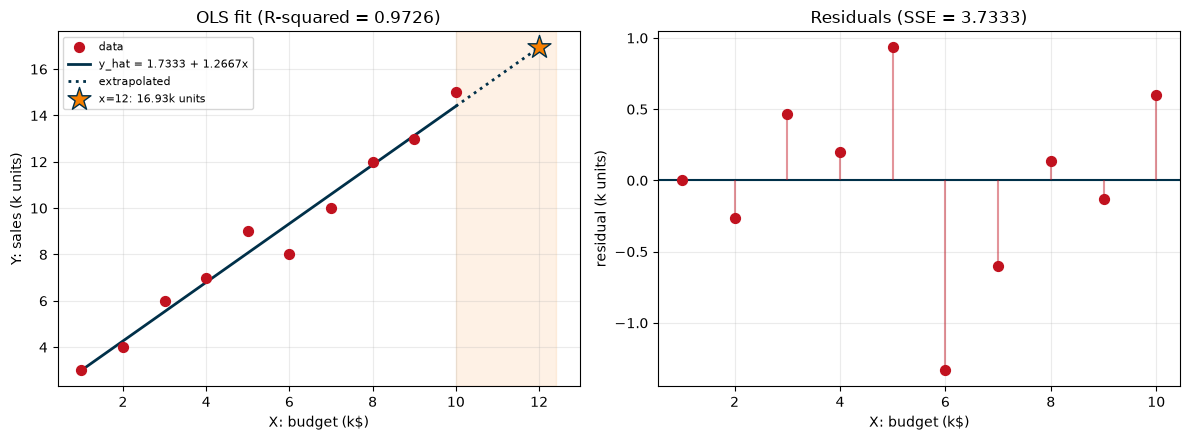

In [9]:
from pathlib import Path

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

line_x = np.linspace(x.min(), x.max(), 100)
extrap_x = np.linspace(x.max(), x_new, 50)

ax1.axvspan(x.max(), x_new + 0.4, color="#f77f00", alpha=0.10)
ax1.scatter(x, y, color="#c1121f", s=50, zorder=3, label="data")
ax1.plot(line_x, beta0 + beta1 * line_x, color="#003049", lw=2,
         label=f"y_hat = {beta0:.4f} + {beta1:.4f}x")
ax1.plot(extrap_x, beta0 + beta1 * extrap_x, color="#003049", lw=2, ls=":",
         label="extrapolated")
ax1.scatter([x_new], [y_pred], marker="*", s=300, color="#f77f00",
            edgecolor="#003049", zorder=4, label=f"x=12: {y_pred:.2f}k units")
ax1.set_xlabel("X: budget (k$)")
ax1.set_ylabel("Y: sales (k units)")
ax1.set_title(f"OLS fit (R-squared = {r_squared:.4f})")
ax1.legend(fontsize=8, loc="upper left")
ax1.grid(alpha=0.25)

ax2.axhline(0, color="#003049", lw=1.5)
ax2.vlines(x, 0, residuals, color="#c1121f", alpha=0.45, lw=1.5)
ax2.scatter(x, residuals, color="#c1121f", s=50, zorder=3)
ax2.set_xlabel("X: budget (k$)")
ax2.set_ylabel("residual (k units)")
ax2.set_title(f"Residuals (SSE = {sse:.4f})")
ax2.grid(alpha=0.25)

fig.tight_layout()
Path("figures").mkdir(exist_ok=True)
fig.savefig("figures/fit_and_residuals.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 3b. Interpretation of R-squared

$$R^2 = 0.9726$$

In [10]:
rmse = np.sqrt(sse / n)
print(f"R^2 = {r_squared:.4f}  -> {r_squared * 100:.2f}% of the variance in sales explained, "
      f"{(1 - r_squared) * 100:.2f}% unexplained")
print(f"typical miss = {rmse:.4f} k units (about {rmse * 1000:,.0f} units, "
      f"{rmse / y_bar * 100:.1f}% of mean sales)")

R^2 = 0.9726  -> 97.26% of the variance in sales explained, 2.74% unexplained
typical miss = 0.6110 k units (about 611 units, 7.0% of mean sales)


**Your explanation**

> _Write here._

<details><summary>Numbers you can cite</summary>

- 97.26% of the variation in sales is explained by the advertising budget; 2.74% is not.
- SST is the error of always predicting y_bar = 8.7 k units; SSE is what the fitted line leaves.
- Very strong fit; typical miss about 0.61 k units (about 611 units, 7% of mean sales).
- Residual plot shows no pattern -> a straight line is an appropriate shape.
- Limits: fit to the training data only, not predictive accuracy; not causation; n = 10 is small.

</details>

---
## Summary

In [11]:
pd.DataFrame([
    ["1b", "beta_0", f"{beta0:.4f}", "k units"],
    ["1b", "beta_1", f"{beta1:.4f}", "k units / k$"],
    ["1c", "fitted line", f"y_hat = {beta0:.4f} + {beta1:.4f} x", ""],
    ["2b", "y_hat(12)", f"{y_pred:.4f}", f"k units (~{y_pred * 1000:,.0f} units), extrapolation"],
    ["3a", "SSE / SST", f"{sse:.4f} / {sst:.4f}", ""],
    ["3a", "R^2", f"{r_squared:.4f}", f"{r_squared * 100:.2f}%"],
], columns=["Task", "Quantity", "Value", "Note"])

,Task,Quantity,Value,Note
0,1b,beta_0,1.7333,k units
1,1b,beta_1,1.2667,k units / k$
2,1c,fitted line,y_hat = 1.7333 + 1.2667 x,
3,2b,y_hat(12),16.9333,"k units (~16,933 units), extrapolation"
4,3a,SSE / SST,3.7333 / 136.1000,
5,3a,R^2,0.9726,97.26%
